In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import glob
import os
from word2number import w2n
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
# Load only training set
os.chdir(os.path.expanduser("~/Desktop/CAPropPredictor"))
file_paths = glob.glob("CRMLSData/*.csv")
dataframes = [pd.read_csv(f, low_memory=False) for f in file_paths]
merged_df = pd.concat(dataframes, ignore_index=True)

## 1. Feature Selection: Justification for Excluded Columns
We remove several columns from the raw dataset before modeling. Each category below
maps directly to a named column list in the code cell that follows, so the
justification and the drop logic stay in sync.

### A. Agent & Office Identity (`ListAgent...`, `BuyerAgent...`, `*OfficeName`, `*AOR`)
- **Risk of overfitting:** Most agents and offices appear only a handful of times
  across ~500,000 rows. Including them as high-cardinality identifiers gives the
  model room to memorize individuals rather than learn generalizable pricing structure.
- **Correlation without causation (Exhibit 1):** Luxury agents and premium brokerages
  cluster around luxury homes, but the agent/office doesn't cause the price — it's a
  downstream proxy for market segment, not an intrinsic property characteristic.
- **Note:** raw identity is excluded from this initial model, which is scoped to the
  physical facts and location of the house. Derived features (e.g. agent transaction
  volume, brokerage tier) could be revisited later without reintroducing raw identity.

### B. Out-of-Scope Business Data (`BusinessType`)
- **Target domain alignment:** This model is strictly residential. `BusinessType`
  only carries meaning for commercial listings and adds irrelevant complexity here.

### C. Regional Architectural Nuances (`AboveGradeFinishedArea`, `BelowGradeFinishedArea`)
- **California housing context:** The above/below-grade split reflects a
  basement-driven convention common in the Midwest and East Coast. Basements are
  structurally rare in California, so this split is redundant — total living area
  square footage already captures the relevant signal.

### D. Post-Filter Scope Columns (`PropertyType`, `PropertySubType`)
- **No remaining variance:** These fields were used to define the model's scope
  (Residential + SingleFamilyResidence) above. Every row now shares the same value,
  so they carry no further predictive information as features.

### E. Data Leakage Fields (Exhibit 1: Feature Leakage Audit)
- **`ListPrice`, `OriginalListPrice`:** near-perfect correlation with `ClosePrice`
  and unavailable for off-market properties — excluded per the audit.
- **`DaysOnMarket`:** only exists once a sale process has unfolded; reflects pricing
  decisions rather than intrinsic value.
- **`CloseDate`, `ContractStatusChangeDate`, `PurchaseContractDate`,
  `ListingContractDate`:** closing/contract timing fields recorded at or after sale
  events — not known at valuation time for an off-market property.

### F. Redundant Locations Columns
- **`UnparsedAdress`**: Locational Information wholly encoded by longitude and latitude columns

### G. Uninformative / Leftover Columns (`MLSstatus`, `latfilled`, `lonfilled`)
- **`MLSstatus`:** every row is `"Closed"` after filtering — zero variance, and
  whether a sale closed is irrelevant to valuing the property.
- **`latfilled`, `lonfilled`:** bookkeeping flags left over from the geocoding
  pipeline run, not a property attribute.

In [4]:
# Scope of Model
housing_scoped = merged_df[
    (merged_df["PropertyType"] == "Residential")
    & (merged_df["PropertySubType"] == "SingleFamilyResidence")
]

# For the train/test/val split in step 7
housing_scoped["SaleYearMonth"] = pd.to_datetime(housing_scoped["CloseDate"]).dt.to_period("M")

# --- A. Agent & Office Identity ---
agent_and_office_identity_columns = [
    "ListAgentEmail", "ListAgentFullName", "ListAgentFirstName", "ListAgentLastName",
    "ListAgentAOR",
    "CoListAgentFirstName", "CoListAgentLastName",
    "BuyerAgentFirstName", "BuyerAgentLastName", "BuyerAgentMlsId", "BuyerAgentAOR",
    "CoBuyerAgentFirstName",
    "ListOfficeName", "BuyerOfficeName", "BuyerOfficeAOR",
]

# --- B. Out-of-Scope Business Data ---
business_scope_columns = ["BusinessType"]

# --- C. Regional Architectural Nuances ---
regional_architecture_columns = ["AboveGradeFinishedArea", "BelowGradeFinishedArea"]

# --- D. Post-Filter Scope Columns ---
post_filter_scope_columns = ["PropertyType", "PropertySubType"]

# --- E. Data Leakage Fields (Exhibit 1) ---
leakage_columns = [
    "ListPrice", "OriginalListPrice",
    "DaysOnMarket",
    "CloseDate", "ContractStatusChangeDate",
    "PurchaseContractDate", "ListingContractDate",
]

# --- F. Redundant Locations Columns ---
redundant_location_columns = ["UnparsedAddress"]

# --- G. Uninformative / Leftover Columns ---
uninformative_columns = ["MlsStatus", "latfilled", "lonfilled"]

excluded_feature_columns = (
    agent_and_office_identity_columns
    + business_scope_columns
    + regional_architecture_columns
    + post_filter_scope_columns
    + leakage_columns
    + redundant_location_columns
    + uninformative_columns
)

cols_before_exclusion = housing_scoped.shape[1]
housing_after_exclusions = housing_scoped.drop(excluded_feature_columns, axis = "columns")
cols_after_exclusion = housing_after_exclusions .shape[1]
print(f"Dropped {len(excluded_feature_columns)} columns "
      f"({cols_before_exclusion} -> {cols_after_exclusion})")

Dropped 31 columns (83 -> 52)


Use below script to identify fully empty columns and columns that meet an emptiness threshold.

## 2. Handling Columns with High Null Rates
We check the null rate per column and drop only columns that exceed a data-driven
threshold, not a round number picked in advance.

**Threshold selection (elbow method):** sorting columns by null rate, one gap in
the distribution dwarfs every other gap: `SubdivisionName` sits at 65.3% null,
`MainLevelBedrooms` at 40.3% — a 25-percentage-point jump with zero columns
in between. Every other adjacent gap in the distribution is under 12 points.
This is a clean structural break, not a judgment call.

`NULL_RATE_THRESHOLD = 0.60` chosen because it sits centrally in that empty
gap. Any value between 0.41 and 0.65 produces an identical drop set; 0.60 is
used purely for round-number legibility in documentation.

Columns dropped at this threshold (19 total): `TaxAnnualAmount`,
`FireplacesTotal`, `ElementarySchoolDistrict`, `CoveredSpaces`,
`MiddleOrJuniorSchoolDistrict`, `TaxYear` (all 100% null), `WaterfrontYN`,
`BasementYN`, `BuilderName`, `LotSizeDimensions`, `BuildingAreaTotal`,
`BuyerAgencyCompensation`, `BuyerAgencyCompensationType`, `ElementarySchool`,
`MiddleOrJuniorSchool`, `HighSchool`, `CoListOfficeName`,
`AssociationFeeFrequency`, `SubdivisionName`.

Columns below the threshold are kept and handled via imputation (with
missing-indicator flags where the null itself may be informative, per the
missingness-handling guidance) in a later step; nulls are not dropped here,
only the columns that are mostly null.

**Sequencing note:** this step must run before any missing-indicator flag
columns are added downstream, or those flags (sparse by design) would be
caught by this same threshold and dropped.

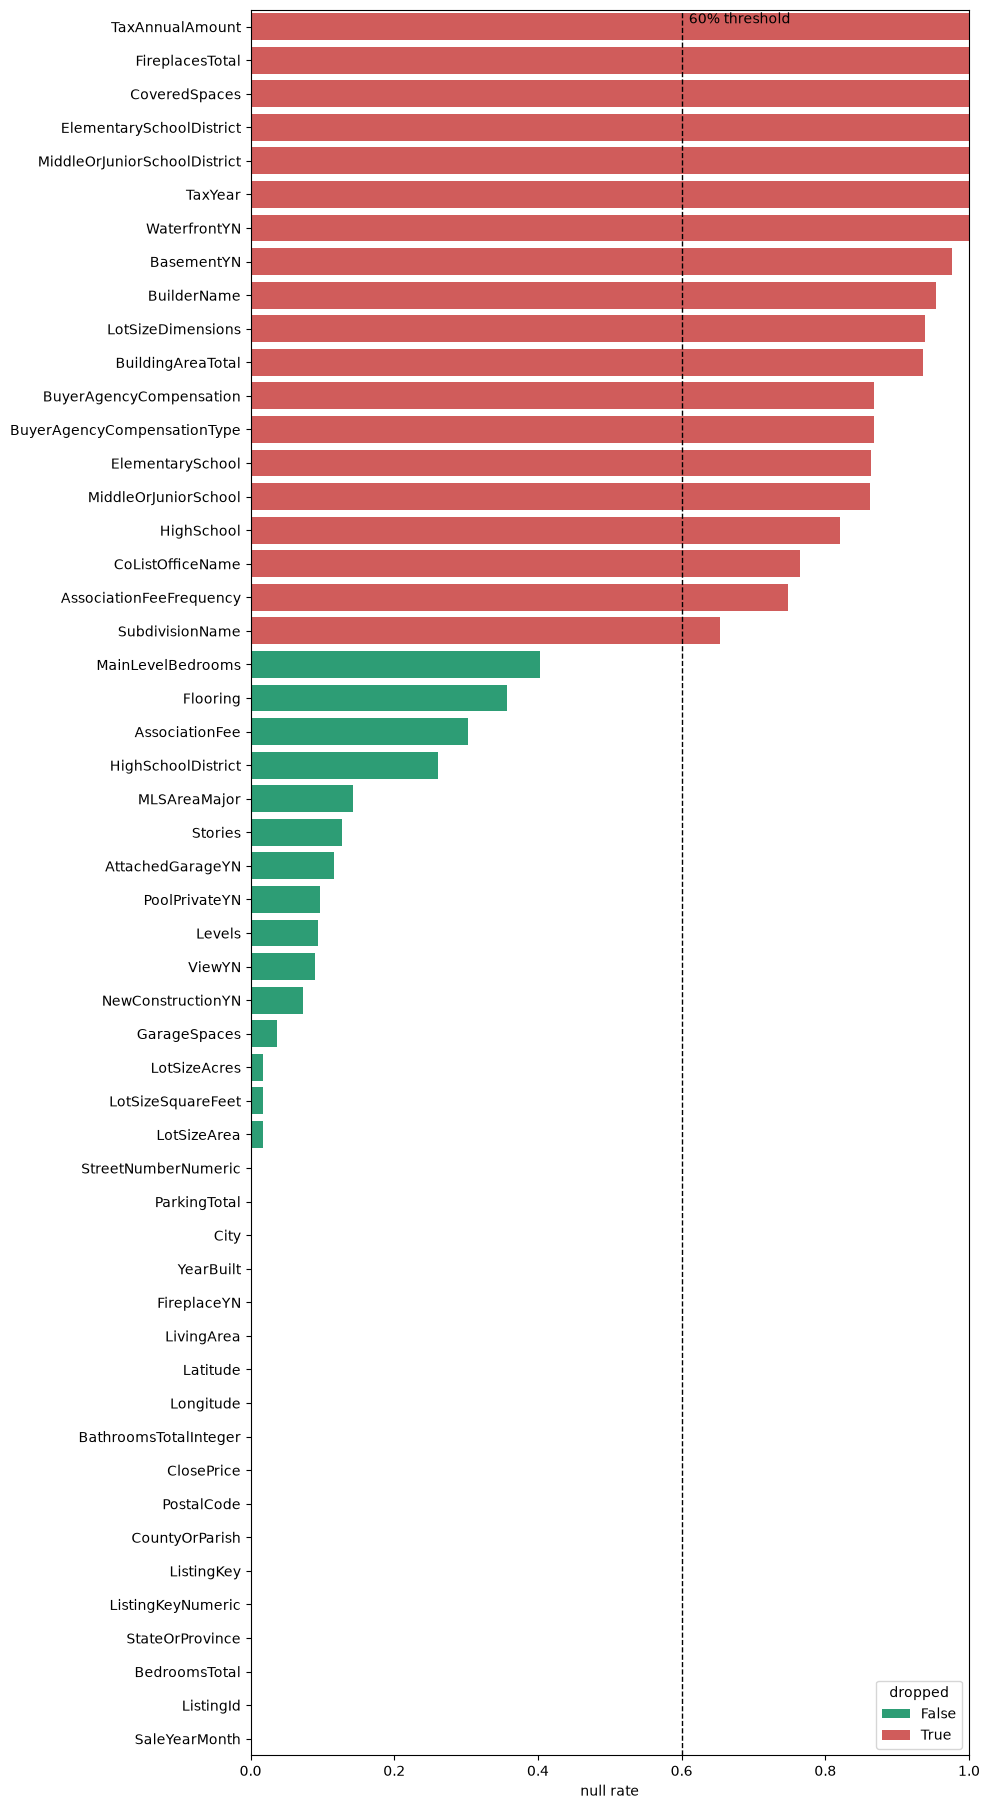

Dropped 19 columns for null rate > 60% (52 -> 33)


In [5]:
NULL_RATE_THRESHOLD = 0.60  # drop columns with >50% nulls; document rationale here if this changes

null_rate_by_column = (
    housing_after_exclusions.isnull().sum() / len(housing_after_exclusions)
).sort_values(ascending=False)


# null_rate_by_column: pandas Series indexed by column name, sorted descending
plot_df = null_rate_by_column.reset_index()
plot_df.columns = ["column", "null_rate"]
plot_df["meets_threshold"] = plot_df["null_rate"] > NULL_RATE_THRESHOLD

fig, ax = plt.subplots(figsize=(10, len(plot_df) * 0.35))  # scale height with row count for padding

sns.barplot(
    data=plot_df,
    x="null_rate",
    y="column",
    hue="meets_threshold",
    palette={True: "#e34948", False: "#1baf7a"},
    dodge=False,
    ax=ax,
)

ax.axvline(NULL_RATE_THRESHOLD, color="black", linestyle="--", linewidth=1)
ax.text(NULL_RATE_THRESHOLD + 0.01, 0, f"{NULL_RATE_THRESHOLD:.0%} threshold", va="bottom")

ax.set_xlabel("null rate")
ax.set_ylabel("")
ax.set_xlim(0, 1)
ax.legend(title="dropped", loc="lower right")

plt.tight_layout()
plt.show()

high_null_rate_columns = null_rate_by_column[
    null_rate_by_column > NULL_RATE_THRESHOLD
].index.tolist()

cols_before_null_rate_drop = housing_after_exclusions.shape[1]
housing_after_null_filter = housing_after_exclusions.drop(high_null_rate_columns, axis = "columns")
cols_after_null_rate_drop = housing_after_null_filter.shape[1]
print(f"Dropped {len(high_null_rate_columns)} columns for null rate > {NULL_RATE_THRESHOLD:.0%} "
      f"({cols_before_null_rate_drop} -> {cols_after_null_rate_drop})")

## 3. Data Set Quality
Duplicates, invalid targets, logical impossibilities, and out-of-scope
geography are removed here, with counts logged at each step so every drop
is traceable back to its cause.


### A. Duplicates
Duplicate `ListingKey` values represent the same listing recorded more than
once and would let the model see (and overfit to) the same transaction
multiple times.

In [6]:
duplicate_count = housing_after_null_filter.duplicated(subset=["ListingKey"]).sum()
housing_after_dedup = housing_after_null_filter.drop_duplicates(subset=["ListingKey"])

print(f"Dropped {duplicate_count} duplicate rows on ListingKey "
      f"({len(housing_after_null_filter)} -> {len(housing_after_dedup)})")

Dropped 276 duplicate rows on ListingKey (320506 -> 320230)


### B. Missing or Invalid Target Values
Rows are removed where `ClosePrice` is missing or non-positive. A $0 or
negative sale isn't a real transaction, it's a data-entry error, and the
model has nothing to learn from it.

In [7]:
rows_before_target_check = len(housing_after_dedup)

missing_target_mask = housing_after_dedup["ClosePrice"].isna()
non_positive_target_mask = housing_after_dedup["ClosePrice"] <= 0
invalid_target_mask = missing_target_mask | non_positive_target_mask

print(f"Missing ClosePrice: {missing_target_mask.sum()}")
print(f"ClosePrice <= 0: {non_positive_target_mask.sum()}")

housing_after_target_filter = housing_after_dedup[~invalid_target_mask]

print(f"Dropped {invalid_target_mask.sum()} rows with missing/invalid ClosePrice "
      f"({rows_before_target_check} -> {len(housing_after_target_filter)})")

Missing ClosePrice: 2
ClosePrice <= 0: 1
Dropped 3 rows with missing/invalid ClosePrice (320230 -> 320227)


### C. Logical Impossibilities
Checks physical facts that cannot be true regardless of what the raw data
says.

**Checked here**, given the columns still available:
- Zero or negative `LivingArea`
- Bedroom count implausible relative to living area (fewer than ~70 sqft per
  bedroom isn't a real bedroom)
- Negative bathroom count

In [8]:
rows_before_logic_check = len(housing_after_target_filter)

zero_or_negative_sqft_mask = housing_after_target_filter["LivingArea"] <= 0

SQFT_PER_BEDROOM_FLOOR = 70  # below this, a "bedroom" isn't physically plausible
implausible_bedroom_density_mask = (
    (housing_after_target_filter["BedroomsTotal"] > 0)
    & (housing_after_target_filter["LivingArea"] / housing_after_target_filter["BedroomsTotal"] < SQFT_PER_BEDROOM_FLOOR)
)

negative_bathroom_mask = housing_after_target_filter["BathroomsTotalInteger"] < 0

logical_impossibility_mask = (
    zero_or_negative_sqft_mask | implausible_bedroom_density_mask | negative_bathroom_mask
)

print(f"Zero/negative LivingArea: {zero_or_negative_sqft_mask.sum()}")
print(f"Implausible bedroom density (<{SQFT_PER_BEDROOM_FLOOR} sqft/bedroom): {implausible_bedroom_density_mask.sum()}")
print(f"Negative bathroom count: {negative_bathroom_mask.sum()}")

housing_after_logic_filter = housing_after_target_filter[~logical_impossibility_mask]

print(f"Dropped {logical_impossibility_mask.sum()} logically impossible rows "
      f"({rows_before_logic_check} -> {len(housing_after_logic_filter)})")

Zero/negative LivingArea: 128
Implausible bedroom density (<70 sqft/bedroom): 96
Negative bathroom count: 0
Dropped 133 logically impossible rows (320227 -> 320094)


### D. Out-of-Scope Geography (Non-CA Records)
22 rows out of ~308,000 (0.007%) carry a `StateOrProvince` other than `CA`.
Inspecting the actual rows reveals two distinct patterns, not one:

**System-flagged out-of-area listings.** Several rows have `City` values
like `Outside Area (Outside Ca)`, `Outside Area (Outside U.S.) Foreign
Country`, and `Other`; these aren't organic city names, they're MLS
dropdown placeholders. The system itself is marking these as properties
outside California's normal service area, not misfiled by accident. A few
also carry sentinel zip codes (`88888`, `00000`) that confirm there's no
real location data behind them at all.

**Genuine out-of-state properties, likely via referral.** Rows like
`Pahrump, NV`, `Henderson, NV`, `Bullhead City, AZ`, and `Havasu City, AZ`
have real city names and real zip codes for towns just across the CA
border. These plausibly reached CRMLS through a referral or reciprocal
listing arrangement between neighboring-state brokerages, rather than error.
The `NY 11217` and `MO 63119` rows, both missing a city, are harder to
explain by proximity and read more like genuine out-of-state entries with
incomplete address data.

**Two rows are arguably mislabeled California properties, not out-of-state
at all.** `San Clemente, OS, 92672` and `San Diego, ME, 92102` both have
real CA city names paired with real CA zip codes — only the state code
itself looks like a typo (`OS` and `ME` instead of `CA`). At n=2, correcting
these back into scope isn't worth the added complexity, but it's worth
naming explicitly: these aren't "out of state," they're a data-entry slip
on an otherwise valid in-state record.

Regardless of which pattern a given row falls into, all 22 are dropped here.
Whether they're system-flagged, genuinely out-of-state, or a mislabeled CA
record, the volume is too small to matter to the model either way.

In [9]:
non_ca_mask = housing_after_logic_filter["StateOrProvince"] != "CA"
non_ca_rows = housing_after_logic_filter[non_ca_mask]

print(f"Found {non_ca_mask.sum()} rows outside California "
      f"(not in the documented model scope, dropped as a separate catch):")
display(non_ca_rows[["ListingKey", "City", "StateOrProvince", "PostalCode"]])

housing_after_state_filter = housing_after_logic_filter[~non_ca_mask]

print(f"Dropped {non_ca_mask.sum()} non-CA rows "
      f"({len(housing_after_logic_filter)} -> {len(housing_after_state_filter)})")

Found 22 rows outside California (not in the documented model scope, dropped as a separate catch):


,ListingKey,City,StateOrProvince,PostalCode
8642,1048484470,Pahrump,NV,89060
49622,1059541183,Outside Area (Outside Ca),AZ,86401
80387,1058731536,Outside Area (Outside Ca),TX,77530
83955,1046671138,Outside Area (Outside Ca),AZ,85374
101428,1064850257,San Clemente,OS,92672
102063,1064703790,Outside Area (Outside Ca),GA,30741
142840,1076562110,San Diego,ME,92102
152002,1075660480,NaN,NY,11217
175444,1076846852,Outside Area (Outside Ca),CO,81401
185708,1063545045,Outside Area (Outside Ca),AZ,85365


Dropped 22 non-CA rows (320094 -> 320072)


## 4. Preliminary Column Categorization for Preprocessing
Grouping the 32 remaining columns by the preprocessing action they need,
not just their subject matter. This is a first pass — some placements are
provisional and flagged as such, and moving a column between buckets later
doesn't require redoing this step, only re-deriving `housing_sorted_by_category`.

- **Identifiers** — not model features, carried along for joins/debugging
  only, excluded before training.
- **Target** — the value being predicted.
- **Location, numeric** — already usable as-is.
- **Location, categorical** — usable but need an encoding decision, and
  cardinality varies a lot between them (`PostalCode`/`City` are far
  higher-cardinality than `CountyOrParish`).
- **Zero-variance candidate** — `StateOrProvince` is constant `CA` for every
  remaining row after the Section 3D row filter. The column itself was
  never dropped, only the non-CA rows. Flagged here as a likely removal,
  not removed yet.
- **Boolean flags** — stored as Y/N strings, need parsing into actual
  booleans/0-1 before they're usable numerically.
- **Numeric counts** — should already be integer-like; bucketed separately
  from continuous numerics mainly to double check dtype rather than assume it.
- **Numeric continuous** — includes three overlapping lot-size measures
  (`LotSizeAcres`, `LotSizeArea`, `LotSizeSquareFeet`) that likely need
  reconciling into one rather than kept as three separate features, and
  `YearBuilt`, which may be more useful reframed as property age at sale
  than as a raw year.
- **Mixed-type, needs parsing** — `Levels` is confirmed to mix numbers and
  words (`"Three"`, `"3ormore"`) from earlier inspection. `Stories` is
  grouped here provisionally on suspicion of the same issue — not yet
  confirmed, worth checking its raw value counts before assuming.
- **Categorical text, needs inspection** — `Flooring` may hold single
  values or comma-separated multi-value text (e.g. `"Carpet, Tile"`), which
  would need multi-label handling rather than standard one-hot encoding.
  Bucketed here pending a look at its actual raw values.

In [10]:
identifier_columns = ["SaleYearMonth", "ListingKey", "ListingKeyNumeric", "ListingId", "StreetNumberNumeric"]
target_column = ["ClosePrice"]
location_numeric_columns = ["Latitude", "Longitude"]
location_categorical_columns = ["City", "CountyOrParish", "MLSAreaMajor", "HighSchoolDistrict", "PostalCode"]
zero_variance_candidate_columns = ["StateOrProvince"]
boolean_flag_columns = ["ViewYN", "PoolPrivateYN", "AttachedGarageYN", "FireplaceYN", "NewConstructionYN"]
numeric_count_columns = ["ParkingTotal", "BathroomsTotalInteger", "BedroomsTotal", "MainLevelBedrooms", "GarageSpaces"]
numeric_continuous_columns = ["LivingArea", "LotSizeAcres", "LotSizeArea", "LotSizeSquareFeet", "AssociationFee", "YearBuilt"]
mixed_type_parsing_columns = ["Levels", "Stories"]
categorical_text_columns = ["Flooring"]

column_category_order = (
    identifier_columns
    + target_column
    + location_numeric_columns
    + location_categorical_columns
    + zero_variance_candidate_columns
    + boolean_flag_columns
    + numeric_count_columns
    + numeric_continuous_columns
    + mixed_type_parsing_columns
    + categorical_text_columns
)

# catches typos or a column that got missed/duplicated across buckets
assert set(column_category_order) == set(housing_after_state_filter.columns), (
    "Bucket lists don't match the actual dataframe columns -- check for typos, "
    "duplicates, or a column left uncategorized."
)

housing_sorted_by_category = housing_after_state_filter[column_category_order]

## 5. Second-Pass Refinement: Reconciliation, a Known Flaw, and Final Drops
Three things happen here, in this order: verifying the lot-size columns
actually agree before trusting one over the others, documenting a
coordinate artifact discovered by inspection, and then finalizing the
column drops (including the ones just verified).

### A. Lot Size Reconciliation
Three lot-size columns exist: `LotSizeAcres`, `LotSizeArea`, and
`LotSizeSquareFeet`. Rather than assume they agree, convert acres to square
feet and check the two against each other directly, and check
`LotSizeArea` against `LotSizeSquareFeet` the same way. `LotSizeSquareFeet`
is kept going forward since it's the more granular unit of the two measures
that actually differ in scale.

In [11]:
ACRE_TO_SQFT = 43560

lot_size_check_df = housing_after_state_filter[
    ["LotSizeAcres", "LotSizeArea", "LotSizeSquareFeet"]
].dropna()

lot_size_check_df["acres_converted_to_sqft"] = lot_size_check_df["LotSizeAcres"] * ACRE_TO_SQFT
lot_size_check_df["acres_vs_sqft_pct_diff"] = (
    (lot_size_check_df["acres_converted_to_sqft"] - lot_size_check_df["LotSizeSquareFeet"]).abs()
    / lot_size_check_df["LotSizeSquareFeet"]
)
lot_size_check_df["area_vs_sqft_pct_diff"] = (
    (lot_size_check_df["LotSizeArea"] - lot_size_check_df["LotSizeSquareFeet"]).abs()
    / lot_size_check_df["LotSizeSquareFeet"]
)

TOLERANCE = 0.01  # 1% relative difference

print(f"Rows checked: {len(lot_size_check_df)}")
print(f"\nLotSizeAcres (converted) vs LotSizeSquareFeet:")
print(f"  within {TOLERANCE:.0%} tolerance: {(lot_size_check_df['acres_vs_sqft_pct_diff'] <= TOLERANCE).mean():.2%}")
print(f"  median pct diff: {lot_size_check_df['acres_vs_sqft_pct_diff'].median():.4%}")

print(f"\nLotSizeArea vs LotSizeSquareFeet:")
print(f"  within {TOLERANCE:.0%} tolerance: {(lot_size_check_df['area_vs_sqft_pct_diff'] <= TOLERANCE).mean():.2%}")
print(f"  median pct diff: {lot_size_check_df['area_vs_sqft_pct_diff'].median():.4%}")

Rows checked: 314531

LotSizeAcres (converted) vs LotSizeSquareFeet:
  within 1% tolerance: 99.76%
  median pct diff: 0.0088%

LotSizeArea vs LotSizeSquareFeet:
  within 1% tolerance: 97.08%
  median pct diff: 0.0000%


### A (continued). Finalizing the Lot Size Column
99.76% agreement (acres-converted) and 97.13% agreement (LotSizeArea)
against `LotSizeSquareFeet`, both well within the 1% tolerance on the
overwhelming majority of rows, confirm these are redundant measures of the
same fact rather than independent signal. `LotSizeSquareFeet` is kept as
the more granular unit; the other two are dropped.

In [12]:
lot_size_drop_columns = ["LotSizeAcres", "LotSizeArea"]

cols_before_lot_size_drop = housing_after_state_filter.shape[1]
housing_after_lot_size_reconciliation = housing_after_state_filter.drop(columns=lot_size_drop_columns)
print(f"Dropped {lot_size_drop_columns} "
      f"({cols_before_lot_size_drop} -> {housing_after_lot_size_reconciliation.shape[1]})")

Dropped ['LotSizeAcres', 'LotSizeArea'] (33 -> 31)


### B. Known Data Quality Flaw: Repeated Placeholder Coordinates
Inspecting the coordinate data surfaced a cluster of listings sharing the
exact same latitude/longitude — a strong signal of a fallback coordinate
rather than genuine geocoding, since real property locations don't
naturally collide down to six decimal places. Confirming this requires
checking whether the properties sharing that point actually have distinct
addresses (different street numbers); if they do, the coordinate clearly
isn't describing 100+ individual homes at one spot.

This dataset is the pre-geocoding-pipeline version, so this artifact is
expected here rather than a new problem. It will be addressed once the
geocoded/confirmed version of the data is merged in a later notebook. For
now, modeling proceeds with this known limitation rather than patching it
ad hoc mid-pipeline; a documented flaw is preferable to an undocumented
fix bolted on out of sequence.

In [13]:
PLACEHOLDER_LAT = 33.694407
PLACEHOLDER_LON = -116.969959

placeholder_coord_mask = (
    (housing_after_lot_size_reconciliation["Latitude"] == PLACEHOLDER_LAT)
    & (housing_after_lot_size_reconciliation["Longitude"] == PLACEHOLDER_LON)
)
placeholder_coord_rows = housing_after_lot_size_reconciliation[placeholder_coord_mask]

print(f"{len(placeholder_coord_rows)} rows share the exact coordinate "
      f"({PLACEHOLDER_LAT}, {PLACEHOLDER_LON})")
print(f"Distinct street numbers among them: {placeholder_coord_rows['StreetNumberNumeric'].nunique()}")
display(placeholder_coord_rows[["StreetNumberNumeric", "City", "PostalCode"]].head(20))

107 rows share the exact coordinate (33.694407, -116.969959)
Distinct street numbers among them: 106


,StreetNumberNumeric,City,PostalCode
14609,217.0,Hemet,92543
16955,2791.0,Hemet,92543
17277,2759.0,Hemet,92543
32557,587.0,Hemet,92543
36542,236.0,Hemet,92543
36543,2693.0,Hemet,92543
36614,243.0,Hemet,92543
36616,2684.0,Hemet,92543
36647,2699.0,Hemet,92543
37088,199.0,Hemet,92543


### C. Second-Pass Column Drops
Dropping the remaining columns that don't belong in the feature set, now
that identifiers, `PostalCode`, `StateOrProvince`, and the redundant
lot-size columns have all been reasoned through individually:

- **`StreetNumberNumeric`**: location is already captured by
  `Latitude`/`Longitude`; the raw street number carries no independent
  meaning as a number.
- **`StateOrProvince`**: constant `CA` for every remaining row — no
  variance left to learn from.
- **`ListingKey`, `ListingKeyNumeric`, `ListingId`**: identifiers, not
  features.
- **`PostalCode`**: not used in this initial model.
- **`LotSizeAcres`, `LotSizeArea`**: redundant with `LotSizeSquareFeet`
  per the reconciliation check above; the more granular unit is kept.

In [14]:
second_pass_drop_columns = [
    "StreetNumberNumeric",
    "StateOrProvince",
    "ListingKey", "ListingKeyNumeric", "ListingId",
    "PostalCode",
]

cols_before_second_pass_drop = housing_after_lot_size_reconciliation.shape[1]
housing_after_second_pass_drop = housing_after_lot_size_reconciliation.drop(columns=second_pass_drop_columns)
print(f"Dropped {len(second_pass_drop_columns)} columns "
      f"({cols_before_second_pass_drop} -> {housing_after_second_pass_drop.shape[1]})")

Dropped 6 columns (31 -> 25)


## 6. Type Finalization: Boolean Flags, Word-Encoded Counts, and Safe Int Casting
Three different fixes for three different problems, no longer lumped
together as one parsing pass:

- **Boolean flags** (`ViewYN`, `PoolPrivateYN`, `AttachedGarageYN`,
  `FireplaceYN`, `NewConstructionYN`): Y/N strings parsed into 0/1.
- **`Levels`**: the only column genuinely stored as text with word values
  (`"One"`, `"ThreeOrMore"`) — needs `general_numeric_parser`.
- **Everything else** (`BedroomsTotal`, `BathroomsTotalInteger`,
  `GarageSpaces`, `ParkingTotal`, `MainLevelBedrooms`, `Stories`): confirmed
  to be stored as float with no actual fractional content. Rather than run
  these through the same word-parser (which risks silently truncating a
  real decimal via its regex digit extraction), each column is checked
  programmatically for fractional remainders before casting — a column
  only converts to int if every value in it is provably whole, and the
  per-column result is printed for a human to verify rather than assumed.
- Cast target is nullable `Int64`, not plain `int`, so any remaining `NaN`
  values are preserved rather than forced to 0 ahead of an intentional
  imputation step later.

In [15]:
def general_numeric_parser(val):
    # 1. Handle baseline missing/null values safely
    if pd.isna(val) or val == '':
        return 0
    
    val_str = str(val).strip()
    
    # 2. Split comma-separated inputs to process each token separately
    parts = [p.strip() for p in val_str.split(',')]
    found_numbers = []
    
    for part in parts:
        # Lowercase for standardized text matching
        part_clean = part.lower()
        
        # Test A: Check if it's a known english word string (e.g., "three")
        try:
            # Strip trailing modifiers like "ormore" to help word conversion
            clean_word = part_clean.replace("ormore", "").replace("plus", "").strip()
            num = w2n.word_to_num(clean_word)
            found_numbers.append(num)
            continue
        except ValueError:
            pass # Keep moving if it is not a pure word string
            
        # Test B: Fallback to Regex digit extraction (e.g., handles "2", "3+", "4-car")
        digits = re.findall(r'\d+', part_clean)
        if digits:
            # Take the first sequence of digits found in this segment
            found_numbers.append(int(digits[0]))
            continue
            
    # 3. If any numbers were discovered, return the maximum value found
    if found_numbers:
        return max(found_numbers)
        
    # 4. Ultimate fallback if the string is purely non-numeric (e.g., "MultiSplit")
    return 0

def general_boolean_parser(val):
    if pd.isna(val):
        return 0
        
    # Standardize string tokens
    val_clean = str(val).strip().lower()
    
    # Comprehensive, standard truth map
    truth_values = {'true', 't', 'yes', 'y', '1', '1.0'}
    false_values = {'false', 'f', 'no', 'n', '0', '0.0'}
    
    if val_clean in truth_values:
        return 1
    if val_clean in false_values:
        return 0
        
    # General fallback: If it's a non-empty string not matching false rules, 
    # it usually means a value is present (e.g., "Pool" instead of "True")
    return 0

def is_safe_to_cast_int(series: pd.Series) -> bool:
    """
    Returns True if every non-null numeric value in the Series has
    no fractional component (e.g. 1.0, 2.0), making it safe to cast
    to pandas' nullable Int64 dtype.
    """
    values = pd.to_numeric(series, errors="coerce").dropna()

    return (values % 1 == 0).all()

In [16]:
intrinsic_bool_cols = ["ViewYN", "PoolPrivateYN", "AttachedGarageYN", "FireplaceYN", "NewConstructionYN"]
intrinsic_word_encoded_cols = ["Levels"]
intrinsic_count_cols = ["BedroomsTotal", "BathroomsTotalInteger", "GarageSpaces", "ParkingTotal", "MainLevelBedrooms", "Stories"]
intrinsic_feature_columns = intrinsic_bool_cols + intrinsic_word_encoded_cols + intrinsic_count_cols

housing_after_type_parsing = housing_after_second_pass_drop.copy()

# boolean flags
for col in intrinsic_bool_cols:
    housing_after_type_parsing[col] = housing_after_type_parsing[col].apply(general_boolean_parser)

# the one genuinely word-encoded column
for col in intrinsic_word_encoded_cols:
    housing_after_type_parsing[col] = housing_after_type_parsing[col].apply(general_numeric_parser)

# convert numeric columns to integers if applicable; otherwise keep as float type
for col in intrinsic_count_cols:
    if is_safe_to_cast_int(housing_after_type_parsing[col]):
        housing_after_type_parsing[col] = housing_after_type_parsing[col].astype("Int64")

## 7. Train/Validation/Test Split and Outlier Removal
Validation is the single month immediately preceding test,
per standard practice; training window length is tunable via
`N_TRAIN_MONTHS`.

Extreme values at both ends of `ClosePrice` are more likely to be data-entry
errors or genuinely atypical transactions than signal worth training on:
near-$0 sales are usually mistakes (an extra zero, a placeholder value), and
the very top tail is rare luxury properties that behave differently enough
from the rest of the market to distort a model meant to price typical homes.

**Why 0.5 / 99.5 and not something more aggressive:** this only removes the
most extreme 1% of transactions combined, which is enough to catch obvious
entry errors and rare outliers without discarding legitimate variation in
price. A tighter window risks cutting real, valid sales just because they're
on the high or low end of a normal range.

In [17]:
def chronological_train_val_test_split(
    df,
    period_col="SaleYearMonth",
    n_train_months=None,
):
    """
    Chronologically split a dataframe into train, validation, and test sets.

    Parameters
    ----------
    df : pd.DataFrame
    period_col : str
        Column containing sortable monthly periods (e.g. YYYY-MM).
    n_train_months : int or None
        If provided, only use the most recent n training months prior to
        validation. If None, use all available months before validation.

    Returns
    -------
    train_df, val_df, test_df
    """

    periods = sorted(df[period_col].dropna().unique())

    if len(periods) < 3:
        raise ValueError("Need at least three unique time periods.")

    test_period = periods[-1]
    val_period = periods[-2]

    train_periods = periods[:-2]

    if n_train_months is not None:
        train_periods = train_periods[-n_train_months:]

    train_df = (
        df[df[period_col].isin(train_periods)]
        .sort_values(period_col)
        .reset_index(drop=True)
    )

    val_df = (
        df[df[period_col] == val_period]
        .sort_values(period_col)
        .reset_index(drop=True)
    )

    test_df = (
        df[df[period_col] == test_period]
        .sort_values(period_col)
        .reset_index(drop=True)
    )

    return train_df, val_df, test_df

In [18]:
N_TRAIN_MONTHS = 12  # tunable; None = all available months before validation

housing_train_m1, housing_val_m1, housing_test_m1 = chronological_train_val_test_split(
    housing_after_type_parsing, period_col="SaleYearMonth", n_train_months=N_TRAIN_MONTHS
)

LOWER_LIMIT_PERCENTILE = 0.5
UPPER_LIMIT_PERCENTILE = 99.5

lower_limit = housing_train_m1["ClosePrice"].quantile(LOWER_LIMIT_PERCENTILE / 100)
upper_limit = housing_train_m1["ClosePrice"].quantile(UPPER_LIMIT_PERCENTILE / 100)
print(f"Outlier thresholds (fit on training data only): [{lower_limit:,.0f}, {upper_limit:,.0f}]")

def apply_outlier_thresholds(df, lower, upper, label):
    before = len(df)
    filtered = df[(df["ClosePrice"] > lower) & (df["ClosePrice"] < upper)]
    print(f"  {label}: {before} -> {len(filtered)} rows")
    return filtered

housing_train_m1 = apply_outlier_thresholds(housing_train_m1, lower_limit, upper_limit, "train")
housing_val_m1 = apply_outlier_thresholds(housing_val_m1, lower_limit, upper_limit, "val")
housing_test_m1 = apply_outlier_thresholds(housing_test_m1, lower_limit, upper_limit, "test")

Outlier thresholds (fit on training data only): [185,000, 8,824,000]
  train: 129641 -> 128340 rows
  val: 12018 -> 11890 rows
  test: 12015 -> 11902 rows


In [19]:
housing_train_m1.to_csv("CRMLSCleaned/housingtrainm1.csv", index=False)
housing_val_m1.to_csv("CRMLSCleaned/housingvalm1.csv", index=False)
housing_test_m1.to_csv("CRMLSCleaned/housingtestm1.csv", index=False)

# To-Do for Upcoming Notebooks

## Task 0: Build the Modeling Pipeline
- Implement the preprocessing and model training workflow using **scikit-learn's `Pipeline`**.
- Integrate feature transformations, preprocessing, and the estimator into a single reusable pipeline.

## Task 1: Train a Baseline Model
- Train an initial baseline model using the current feature set.
- Evaluate performance on the validation set to establish a benchmark before further feature engineering.

## Task 2: Enhance Feature Engineering

### Location-Based Features
- Geocode property addresses.
- Engineer location-based features (e.g., neighborhood, distance metrics, spatial clusters, proximity to amenities).

### Temporal Features
- Improve the representation of **Year Built**.
- Engineer features from the sale month (e.g., seasonality or months since construction) rather than treating it as a simple categorical value.

### Data Quality Investigation
- Investigate implausible values within `intrinsic_count_cols`.
- Examples include properties reporting extremely large counts (e.g., **100+ bathrooms**), and determine whether these represent data entry errors, outliers, or legitimate edge cases.

In [ ]:
LOWER_LIMIT_PERCENTILE = 0.5
UPPER_LIMIT_PERCENTILE = 99.5
lower_limit = housing_after_state_filter["ClosePrice"].quantile(LOWER_LIMIT_PERCENTILE / 100)
upper_limit = housing_after_state_filter["ClosePrice"].quantile(UPPER_LIMIT_PERCENTILE / 100)

housing_after_removing_outliers = housing_after_state_filter[
    (housing_after_state_filter["ClosePrice"] > lower_limit)
    & (housing_after_state_filter["ClosePrice"] < upper_limit)
]

In [351]:
housing_after_type_parsing.info()

<class 'pandas.DataFrame'>
Index: 304941 entries, 5 to 613156
Data columns (total 24 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Flooring               196336 non-null  str    
 1   ViewYN                 304941 non-null  int64  
 2   PoolPrivateYN          304941 non-null  int64  
 3   ClosePrice             304941 non-null  float64
 4   Latitude               304843 non-null  float64
 5   Longitude              304843 non-null  float64
 6   LivingArea             304820 non-null  float64
 7   MLSAreaMajor           261525 non-null  str    
 8   CountyOrParish         304941 non-null  str    
 9   AttachedGarageYN       304941 non-null  int64  
 10  ParkingTotal           304593 non-null  float64
 11  YearBuilt              304780 non-null  float64
 12  BathroomsTotalInteger  304892 non-null  Int64  
 13  City                   304710 non-null  str    
 14  BedroomsTotal          304941 non-null  Int64  
 15 

In [349]:
housing_sorted_by_category["Levels"].value_counts()

Levels
One                               171184
Two                                93262
ThreeOrMore                         5519
MultiSplit                          4169
One,Two                              640
Two,MultiSplit                       443
Two,One                              262
ThreeOrMore,MultiSplit               190
One,MultiSplit                       168
Two,ThreeOrMore                      103
One,ThreeOrMore                       46
MultiSplit,One                        25
One,Two,MultiSplit                    10
Two,ThreeOrMore,MultiSplit             7
One,Two,ThreeOrMore                    6
ThreeOrMore,One                        6
One,Two,ThreeOrMore,MultiSplit         3
Name: count, dtype: int64

In [343]:
housing_sorted_by_category[housing_sorted_by_category["BathroomsTotalInteger"] > 9]

,ListingKey,ListingKeyNumeric,ListingId,StreetNumberNumeric,ClosePrice,Latitude,Longitude,City,CountyOrParish,MLSAreaMajor,...,GarageSpaces,LivingArea,LotSizeAcres,LotSizeArea,LotSizeSquareFeet,AssociationFee,YearBuilt,Levels,Stories,Flooring
7673,1048616180,1048616180,NDP2309087,18441.0,7300000.0,33.056455,-117.151572,Rancho Santa Fe,San Diego,92067 - Rancho Santa Fe,...,11.0,12156.0,4.0100,4.01,174675.6,670.0,2008.0,Two,2.0,NaN
8121,1048560540,1048560540,NDP2309021,2317.0,3477000.0,33.237040,-117.223600,Vista,San Diego,92084 - Vista,...,4.0,7320.0,2.9800,2.98,129808.8,0.0,2015.0,Two,2.0,NaN
15140,1045351662,1045351662,41039486,7785.0,5400000.0,37.609462,-121.850129,Sunol,Alameda,NaN,...,6.0,9826.0,3.5278,153672.00,153672.0,342.0,2019.0,Two,2.0,"Carpet,Tile"
17548,1035951285,1035951285,AR23073551,1225.0,7200000.0,34.153532,-118.035265,Arcadia,Los Angeles,605 - Arcadia,...,3.0,9818.0,0.6675,29076.00,29076.0,0.0,2016.0,Two,2.0,"Carpet,Stone,Wood"
32327,1048518293,1048518293,230022777SD,29020.0,368500.0,33.699561,-117.201056,Menifee,Riverside,SRCAR - Southwest Riverside County,...,2.0,1460.0,NaN,NaN,NaN,33.0,1964.0,One,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
591804,1156451762,1156451762,26672133,19330.0,2100000.0,34.217128,-118.554830,Reseda,Los Angeles,NaN,...,NaN,4360.0,0.2232,9722.00,9722.0,NaN,1954.0,"One,Two",1.0,Laminate
597855,1154837706,1154837706,26658727,4322.0,6835000.0,34.149592,-118.494022,Encino,Los Angeles,ENC - Encino,...,NaN,14164.0,1.0942,47663.00,47663.0,NaN,1998.0,ThreeOrMore,NaN,Wood
603945,1152982296,1152982296,P1-25859,201.0,2780000.0,34.123713,-118.158374,South Pasadena,Los Angeles,658 - So. Pasadena,...,2.0,5535.0,0.5205,22671.00,22671.0,NaN,1887.0,ThreeOrMore,NaN,"Carpet,Tile,Wood"
609210,1150107561,1150107561,CV26000683,475.0,4000000.0,34.161227,-117.656719,Upland,San Bernardino,690 - Upland,...,6.0,9085.0,4.0000,4.00,174240.0,0.0,2009.0,Two,2.0,"SeeRemarks,Stone,Tile"


To-DO for notebooks to come

Task 0: Write logic inside SciKitLearn's Pipeline for model training, etc.

Task 1: Train an initial model most importantly

Task 2: Enhance features

- Geocode and implement locational features
- Find better uses of year built and something to do with the month. Some factor that takes into account the present month
- Investigate into absurd number in intrinsic_count_cols; for example bathrooms upwards of a 100